Customer Segmentation (K-Means Clustering)
Objective

Group customers into similar segments based on their financial behavior.

Example:

Segment	Description
Cluster 0	High-value FCY Customers
Cluster 1	Low Activity Customers
Cluster 2	Frequent Remittance Customers
Cluster 3	Digital Banking Customers

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

In [ ]:
#Load the feature engineered dataset.
customers = pd.read_csv("customers_feature_engineered.csv")

customers.head()

,CustomerID,Age,Gender,Occupation,MonthlyIncome,Region,Branch,FCYAccount,ETBAccount,MobileBanking,...,HighIncome,FrequentRemittance,HighRemittance,ActiveCustomer,DigitalCustomer,CustomerValueScore,MonthlyRemittanceAverage,FCYUtilizationRate,RelationshipScore,PotentialFCYCustomer
0,100001,59,Female,Business Owner,71321,Addis Ababa,Adama,Yes,Yes,Yes,...,0,0,1,0,0,24368.8,428.75,0.421186,4,0
1,100002,49,Male,Merchant,144028,Amhara,CMC,No,Yes,No,...,1,1,1,0,0,48416.4,701.33,0.211383,6,1
2,100003,35,Female,Teacher,86131,Addis Ababa,Bole,No,Yes,Yes,...,1,0,1,0,0,29201.8,493.75,0.365063,4,0
3,100004,63,Female,Merchant,37963,Tigray,Megenagna,Yes,Yes,No,...,0,0,0,0,0,13896.4,317.92,0.411271,5,0
4,100005,28,Male,Private Employee,113757,Amhara,CMC,No,Yes,No,...,1,0,0,0,0,36243.6,252.75,0.532476,4,0


In [3]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                500 non-null    int64  
 1   Age                       500 non-null    int64  
 2   Gender                    500 non-null    object 
 3   Occupation                500 non-null    object 
 4   MonthlyIncome             500 non-null    int64  
 5   Region                    500 non-null    object 
 6   Branch                    500 non-null    object 
 7   FCYAccount                500 non-null    object 
 8   ETBAccount                500 non-null    object 
 9   MobileBanking             500 non-null    object 
 10  InternetBanking           500 non-null    object 
 11  RemittanceCount           500 non-null    int64  
 12  TotalRemittanceUSD        500 non-null    int64  
 13  AverageTransactionUSD     500 non-null    float64
 14  FCYPurchas

In [4]:
#Encode Remaining Categorical Columns

#Since K-Means only works with numbers, encode the remaining categorical columns.
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "Gender",
    "Occupation",
    "Region",
    "Branch",
    "FCYAccount",
    "ETBAccount",
    "MobileBanking",
    "InternetBanking",
    "AgeGroup"
]

for column in categorical_columns:
    customers[column] = encoder.fit_transform(customers[column])

In [5]:
#Select Features for Clustering

cluster_features = [

"MonthlyIncome",

"RemittanceCount",

"TotalRemittanceUSD",

"FCYPurchaseUSD",

"ExistingProducts",

"CustomerValueScore",

"RelationshipScore",

"FCYUtilizationRate"

]

X = customers[cluster_features]

In [6]:
#Scale Features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
#Find the Best Number of Clusters
wcss = []

for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

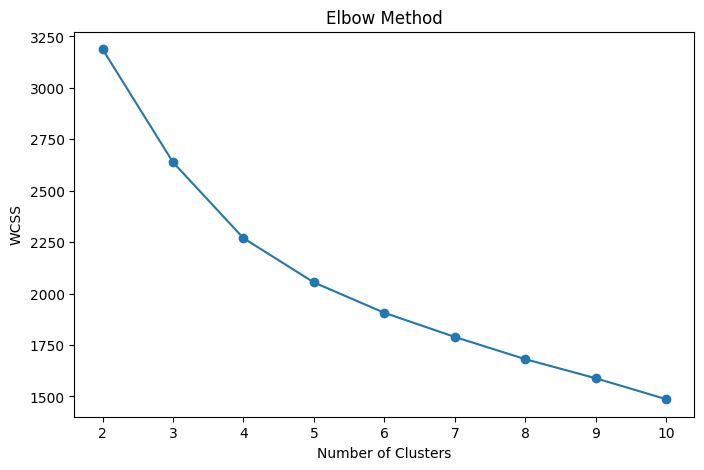

In [ ]:
# The "elbow" is usually around 4 for this synthetic dataset.
plt.figure(figsize=(8,5))

plt.plot(range(2,11),wcss,marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [9]:
#Train K-Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customers["Cluster"] = kmeans.fit_predict(X_scaled)

In [10]:
#Check Cluster Sizes
customers["Cluster"].value_counts()

Cluster
0    144
1    143
2    114
3     99
Name: count, dtype: int64

In [11]:
#Cluster Summary

cluster_summary = customers.groupby("Cluster")[

[
"MonthlyIncome",
"RemittanceCount",
"TotalRemittanceUSD",
"FCYPurchaseUSD",
"CustomerValueScore",
"RelationshipScore"
]

].mean()

cluster_summary

,MonthlyIncome,RemittanceCount,TotalRemittanceUSD,FCYPurchaseUSD,CustomerValueScore,RelationshipScore
Cluster,,,,,,
0,148765.354167,6.256944,4635.048611,2295.256944,47642.963889,5.666667
1,68266.559441,6.517483,4706.783217,2385.461538,23166.226573,3.748252
2,59193.578947,5.578947,3782.350877,2156.578947,20498.371930,6.473684
3,102701.171717,9.767677,8900.131313,5858.898990,35884.659596,5.292929


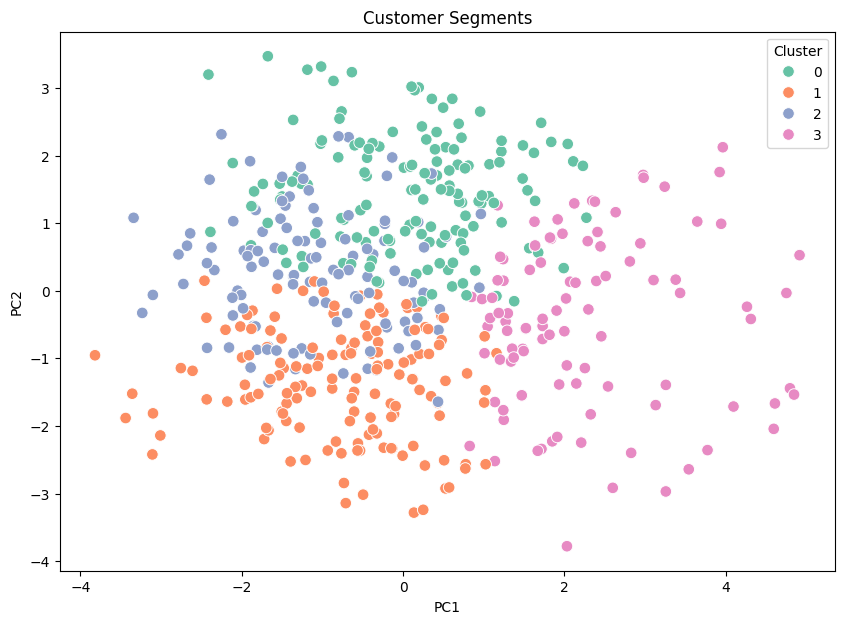

In [12]:
#Visualize Clusters Using PCA
#Since we have many features, reduce them to 2 dimensions.

pca = PCA(n_components=2)

components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": components[:,0],
    "PC2": components[:,1],
    "Cluster": customers["Cluster"]
})

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=70
)

plt.title("Customer Segments")

plt.show()

In [13]:
#Analyze Each Cluster

#Average values by cluster:

customers.groupby("Cluster").agg({

"MonthlyIncome":"mean",

"RemittanceCount":"mean",

"TotalRemittanceUSD":"mean",

"FCYPurchaseUSD":"mean",

"RelationshipScore":"mean",

"LeadStatus":"mean"

}).round(2)

,MonthlyIncome,RemittanceCount,TotalRemittanceUSD,FCYPurchaseUSD,RelationshipScore,LeadStatus
Cluster,,,,,,
0,148765.35,6.26,4635.05,2295.26,5.67,0.12
1,68266.56,6.52,4706.78,2385.46,3.75,0.13
2,59193.58,5.58,3782.35,2156.58,6.47,0.04
3,102701.17,9.77,8900.13,5858.90,5.29,0.53


In [14]:
#Give Business Names

#Instead of Cluster 0, 1, 2...

cluster_names = {

0:"High Value Customers",

1:"Low Activity Customers",

2:"Frequent Remittance Customers",

3:"Digital Banking Customers"

}

In [15]:
customers["CustomerSegment"] = customers["Cluster"].map(cluster_names)


In [16]:
customers[["CustomerID","Cluster","CustomerSegment"]].head()

,CustomerID,Cluster,CustomerSegment
0,100001,1,Low Activity Customers
1,100002,0,High Value Customers
2,100003,1,Low Activity Customers
3,100004,2,Frequent Remittance Customers
4,100005,0,High Value Customers


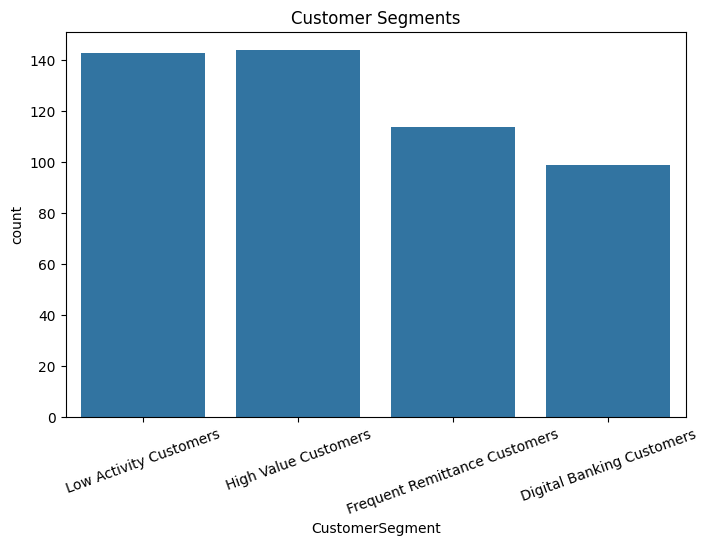

In [17]:
#Distribution of Segments

plt.figure(figsize=(8,5))

sns.countplot(
    data=customers,
    x="CustomerSegment"
)

plt.xticks(rotation=20)

plt.title("Customer Segments")

plt.show()

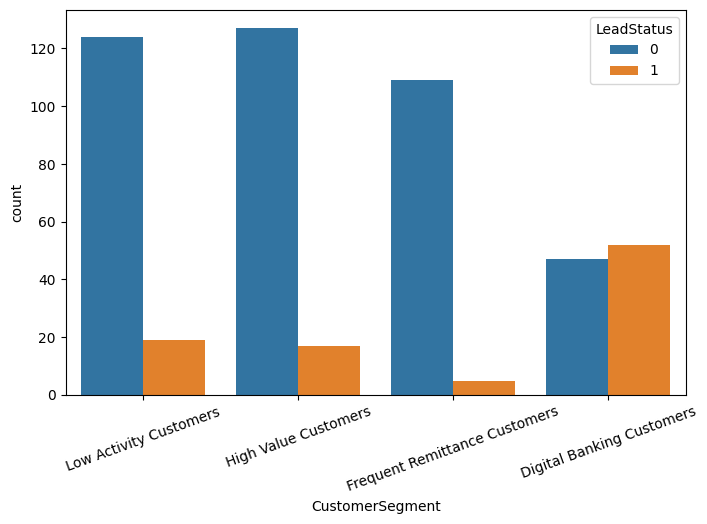

In [18]:
#Segment vs Lead Status
pd.crosstab(

customers["CustomerSegment"],

customers["LeadStatus"]
)

plt.figure(figsize=(8,5))

sns.countplot(
    data=customers,
    x="CustomerSegment",
    hue="LeadStatus"
)

plt.xticks(rotation=20)

plt.show()

In [19]:
customers.to_csv(

"customers_segmented.csv",

index=False

)

print("Segmented dataset saved successfully!")

Segmented dataset saved successfully!


Business Interpretation

At this point, don't assume what each cluster means based only on its numeric ID. Use the cluster summary from Step 10 to assign meaningful names. For example:

Customer Segment	Typical Characteristics	Suggested Action
High Value Customers	High income, high remittance, high relationship score	Assign to Relationship Managers and promote Premium FCY products
Frequent Remittance Customers	Many remittance transactions but no FCY account	Promote FCY Savings and Fixed Deposit
Digital Banking Customers	Strong digital adoption	Target with digital FCY campaigns and personalized offers
Low Activity Customers	Low income, few transactions	General awareness campaigns rather than immediate sales